# **HW3 – Unstructured Search & Grover’s Algorithm**
_Time required: ~2–3 hours (for students with Qiskit query algorithm experience)_

**What you’ll practice**
- Implementing Grover's oracle and diffusion operator
- Building and iterating Grover's circuit
- Handling single and multiple marked states
- Calculating optimal iterations and success probability
- Amplitude amplification analysis
- Applications to search problems in AI/DS

**What to turn in**
- This single notebook (`HW3_YourName.ipynb`) with **all cells run**, code and short written answers filled in where prompted.

**Rules & hints**
- Use **Qiskit** (version ~1.0 or later).
- Use AerSimulator for reproducibility.
- If stuck, explain reasoning; partial credit for clear work.
- For circuits, use `qc.draw('mpl')`; for states, use `Statevector`.
- Use phase oracle where possible (no ancilla).


In [10]:
# --- Setup (run me first) ---
# Install Qiskit if needed (uncomment in Colab)
!pip install qiskit qiskit-aer qiskit-ibm-runtime matplotlib pylatexenc

# Import necessary modules
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector, Operator
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

# Simulator backend
sim = AerSimulator()

# Function to get unitary matrix of a circuit
def unitary_of(circ):
    """Return the unitary matrix of the circuit."""
    return Operator(circ).data

# Function to run circuit and get counts
def get_counts(circ, shots=2000):
    tc = transpile(circ, sim)
    result = sim.run(tc, shots=shots).result()
    return result.get_counts()

def assert_close(A, B, tol=1e-8):
    if not np.allclose(A, B, atol=tol):
        raise AssertionError(f"Not close:\n{A}\nvs\n{B}")


## Part A — Grover's Oracle & Diffusion (≈25 min)

**A1.** Implement a phase oracle for n=2, target '11' (mark |11>). Draw the oracle circuit.  
**A2.** Build the diffusion operator for n=2. Verify its unitary matches 2|s><s| - I.  
**A3.** Short answer: Explain phase kickback in oracle; why no ancilla needed here.


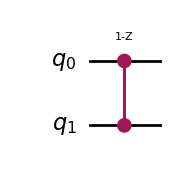

Oracle unitary:
 [[ 1.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  1.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  1.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j -1.+0.j]]


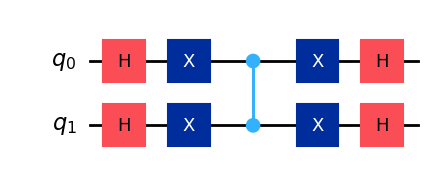

In [13]:
from qiskit.circuit.library import grover_operator, MCMTGate, ZGate
from IPython.display import display
# A1. Phase oracle for n=2, target '11'
TARGET = '11'

n = 2
qc_oracle = QuantumCircuit(n)
target = TARGET

for i, bit in enumerate(target[::-1]):
  if bit == '0':
    qc_oracle.x(i)
qc_oracle.compose(MCMTGate(ZGate(), n - 1, 1), inplace=True)
for i, bit in enumerate(target[::-1]):
  if bit == '0':
    qc_oracle.x(i)
display(qc_oracle.draw('mpl'))
plt.show()
U_oracle = unitary_of(qc_oracle)
print("Oracle unitary:\n", U_oracle)
# Diagonal should be [1,1,1,-1]

# A2. Diffusion for n=2
qc_diff = QuantumCircuit(n)
qc_diff.h(range(n))
qc_diff.x(range(n))
qc_diff.cz(0, 1)
qc_diff.x(range(n))
qc_diff.h(range(n))
# YOUR CODE HERE: h on all, x on all, cz(0,1), x on all, h on all
display(qc_diff.draw('mpl'))
plt.show()
U_diff = unitary_of(qc_diff)
s = np.ones(4)/2  # |s> for n=2
D_expected = (2 * np.outer(s, s) - np.eye(4)) * -1 # -1 is a global phase correction
assert_close(U_diff, D_expected)

# A3. Written answer: (Oracle flips phase on marked; no ancilla since phase oracle directly)


## Part B — Single Grover Iteration (≈20 min)

**B1.** Build initial superposition |s> for n=3. Plot Bloch (or statevector).  
**B2.** Apply one Grover iteration (oracle for target '010' + diffusion). Evolve statevector.  
**B3.** Measure (shots=2000), plot histogram. Explain amplitude boost.


Initial sv:  Statevector([0.35355339+0.j, 0.35355339+0.j, 0.35355339+0.j,
             0.35355339+0.j, 0.35355339+0.j, 0.35355339+0.j,
             0.35355339+0.j, 0.35355339+0.j],
            dims=(2, 2, 2))
After 1 iter:  Statevector([-0.1767767 +0.j, -0.1767767 +0.j, -0.88388348+0.j,
             -0.1767767 +0.j, -0.1767767 +0.j, -0.1767767 +0.j,
             -0.1767767 +0.j, -0.1767767 +0.j],
            dims=(2, 2, 2))


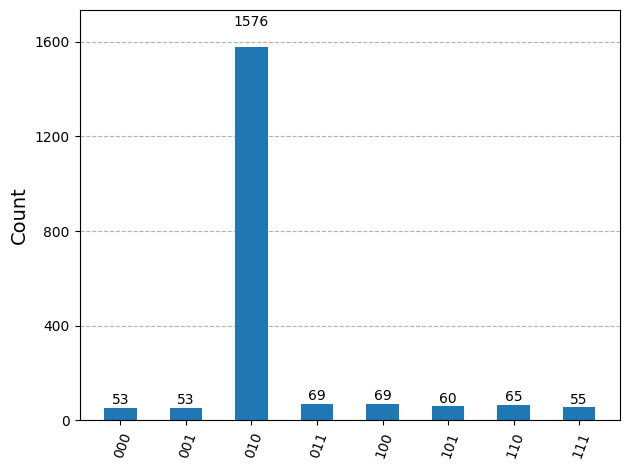

In [14]:
# B1. |s> for n=3
n3 = 3
qc_s = QuantumCircuit(n3)
# YOUR CODE HERE: h on all
qc_s.h(qc_s.qubits)
sv_s = Statevector(qc_s)
print("Initial sv: ", sv_s)

# B2. One iteration: oracle + diffusion
target = 2  # '010' binary = 2
qc_oracle3 = QuantumCircuit(n3)
# YOUR CODE HERE: implement phase oracle for target (multi-controlled Z)
target = bin(target)[2:].zfill(n3)
for i, bit in enumerate(target[::-1]):
  if bit == '0':
    qc_oracle3.x(i)
qc_oracle3.compose(MCMTGate(ZGate(), n3 - 1, 1), inplace=True)
for i, bit in enumerate(target[::-1]):
  if bit == '0':
    qc_oracle3.x(i)

# YOUR CODE HERE: diffusion for n=3 (h, x, multi-cz, x, h)
qc_diff3 = QuantumCircuit(n3)
qc_diff3.h(qc_diff3.qubits)
qc_diff3.x(qc_diff3.qubits)
qc_diff3.compose(MCMTGate(ZGate(), n3 - 1, 1), inplace=True)
qc_diff3.x(qc_diff3.qubits)
qc_diff3.h(qc_diff3.qubits)


qc_grover1 = qc_s.copy()
qc_grover1 = qc_grover1.compose(qc_oracle3)
qc_grover1 = qc_grover1.compose(qc_diff3)
sv_g1 = Statevector(qc_grover1)
print("After 1 iter: ", sv_g1)

# B3. Measure and plot
qc_grover1_meas = qc_grover1.copy()
qc_grover1_meas.measure_all()
counts_g1 = get_counts(qc_grover1_meas)
display(plot_histogram(counts_g1))
plt.show()
# Written answer: (Target amplitude increased; others suppressed via inversion about mean)


## Part C — Multiple Iterations & Optimal k (≈30 min)

**C1.** For n=4 (N=16), M=1 target='1010', compute optimal k ≈ π√N/4.  
**C2.** Build full Grover circuit with k iterations; run (shots=1), check if target found.  
**C3.** Short answer: Derive sin((2k+1)θ) probability; why over-iteration reduces success.


In [5]:
# C1. Optimal k
n4 = 4
N = 2**n4
M = 1
k_opt = round(np.pi * (np.sqrt(n4)/4))  # YOUR CODE HERE: find the best value of k
print("Optimal k: ", k_opt)

# C2. Full Grover
target4 = 10
qc_oracle4 = QuantumCircuit(n4)
target4_bin_str = bin(target4)[:1:-1]
for i, bit in enumerate(target4_bin_str):
  if bit == '0':
    qc_oracle4.x(i)
qc_oracle4.compose(MCMTGate(ZGate(), n4 - 1, 1), inplace=True)
for i, bit in enumerate(target4_bin_str):
  if bit == '0':
    qc_oracle4.x(i)
# YOUR CODE HERE: phase oracle for '1010'
qc_diff4 = QuantumCircuit(n4)
qc_diff4.h(range(n4))
qc_diff4.x(range(n4))
qc_diff4.compose(MCMTGate(ZGate(), n4 - 1, 1), inplace=True)
qc_diff4.x(range(n4))
qc_diff4.h(range(n4))
# YOUR CODE HERE: diffusion for n=4
qc_grover = QuantumCircuit(n4, n4)
qc_grover.h(range(n4))  # |s>
for _ in range(k_opt):
    qc_grover = qc_grover.compose(qc_oracle4)
    qc_grover = qc_grover.compose(qc_diff4)
qc_grover.measure(range(n4), range(n4))
counts_g = get_counts(qc_grover, shots=1)
print("Result: ", counts_g)
# Assert target found

# C3. Written answer: (P = sin^2((2k+1)θ), θ≈arcsin(√(M/N)); over-rotates past π/2)


Optimal k:  2
Result:  {'1010': 1}


## Part D — Multiple Solutions (≈25 min)

**D1.** Modify oracle for M=2 targets ('001','110') in n=3. Compute new k_opt. $\frac{\pi}{4}\sqrt{\frac{N}{M}}$

Where $N$ is the size of the state space, $N=2^n$, and $M$ is the number of marked states.

**D2.** Run Grover with new k; plot histogram (shots=2000).  
**D3.** Short answer: How to estimate M if unknown? (Quantum counting).


New k:  1


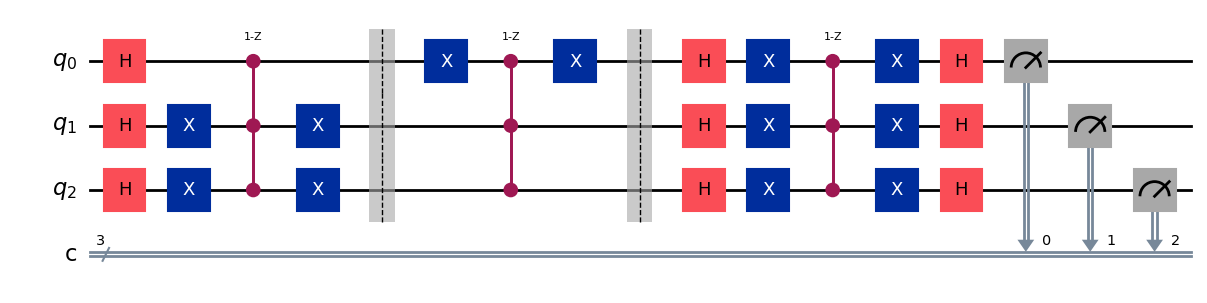

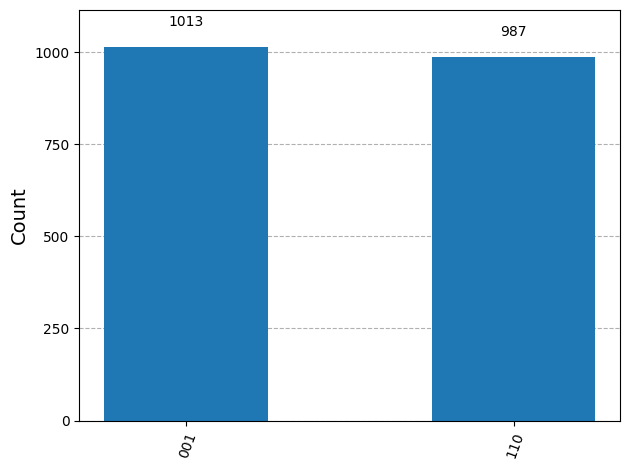

In [17]:
# D1. Multi-target oracle, k_opt
targets = [1, 6]  # '001'=1, '110'=6
M2 = len(targets)
n = len(bin(max(targets))[2:])
k_opt_m = int(np.pi/4 * np.sqrt(2**n/M2))  # YOUR CODE HERE: round(np.pi * np.sqrt(8/M2) / 4 - 0.5)
qc_oracle_m = QuantumCircuit(3)
# YOUR CODE HERE: oracle marking multiple (e.g., sum of projectors or ancilla-based)
for targ in targets:
  targ_bin_str = bin(targ)[2:].zfill(n)
  for i, bit in enumerate(targ_bin_str[::-1]):
    if bit == '0':
      qc_oracle_m.x(i)
  qc_oracle_m.compose(MCMTGate(ZGate(), n - 1, 1), inplace=True)
  for i, bit in enumerate(targ_bin_str[::-1]):
    if bit == '0':
      qc_oracle_m.x(i)
  qc_oracle_m.barrier()
print("New k: ", k_opt_m)

# D2. Run multi
qc_grover_m = QuantumCircuit(3, 3)
qc_grover_m.h(range(3))
for _ in range(k_opt_m):
    qc_grover_m = qc_grover_m.compose(qc_oracle_m)
    qc_grover_m = qc_grover_m.compose(qc_diff3)  # Reuse from earlier
qc_grover_m.measure(range(3), range(3))
display(qc_grover_m.draw('mpl'))
plt.show()
counts_m = get_counts(qc_grover_m)
display(plot_histogram(counts_m))
plt.show()

# D3. Written answer: (Phase estimation on Grover operator G; eigenvalues encode θ ~ arcsin(√(M/N)))


## Part E — Applications & Analysis (≈20 min)

**E1.** Short answer: Prove Grover's O(√N) is optimal (hint: query lower bound).  
**E2.** For a DS search problem (e.g., find anomaly in 2^20 records), compute classical vs quantum queries.  
**E3.** Written reflection: Limitations for real databases; potential in hybrid ML (e.g., amplify rare features).


In [ ]:
# E1. Written answer: (Any quantum alg needs Ω(√N) queries; otherwise adversary distinguishes oracles with few queries.)

# E2. Queries calc
N_ds = 2**20
classical_avg = N_ds / 2
quantum = np.pi * np.sqrt(N_ds) / 4
print("Classical avg: ", classical_avg, " Quantum: ", quantum)

# E3. Written answer: (Oracle must encode full DB coherently—impractical; but useful for sparse optim or amp in QML kernels.)
